This code imports randomly sampled ids from Alberts et al and produces summary plots and statistics to explore the chemical space

In [2]:
import os
import pandas as pd
os.getcwd()

'/Users/jacknugent/Desktop/yale_project_github'

In [3]:
# read in data
# Jack, you will need to change this path to go to your stored data, which might need to be uploaded to Colab
ids_1k = pd.read_pickle('/Users/jacknugent/Downloads/ids_nmr_matched_gaussian_1k.pkl')

In [3]:
# take a look at the data
# smiles are chemical identifiers
# molecular formula is what it sounds like
ids_1k.tail(12)


,smiles,molecular_formula
2882,CC(C)(C)OC(=O)CC(=O)c1cncc(Br)c1,C12H14BrNO3
587,COc1cc(CN)c2c(c1CC(=O)O)Sc1c(ccc(OC)c1C(=O)OC(...,C23H28N2O6S
769,Cc1nc(OCCCC2CCN(C(=O)OC(C)(C)C)CC2)ccc1C(=O)NC...,C23H37N3O6
1446,CC(C)(C)OC(=O)c1cncc(-c2ccc3c(c2)OCO3)c1,C17H17NO4
496,O=C(CN1CCN(Cc2ccc3c(c2)OCO3)CC1)NCC12CC3CC(CC(...,C25H35N3O3
3184,C[C@@H]1CC[C@@H](Cn2c(Br)nc3nc(C#N)nc(N[C@H](C...,C20H27BrN6
2503,CNc1ccc(N2C(=O)N(c3ccc(C#N)c(C(F)(F)F)c3)[C@@H...,C22H20F4N4O
3194,c1ccc(C(c2ccccc2)n2ccc3ccccc32)cc1,C21H17N
2989,COC(=O)c1ccc2c(C(C)=O)nn(CC(=O)OC(C)(C)C)c2c1,C17H20N2O5
1374,CC(C)Cc1ccc(C#Cc2ccc3c(c2)CCCC3=O)cc1,C22H22O


In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

def get_rdkit_props(df, smiles_col):
    """
    df: the pandas dataframe
    smiles_col: the name of the column containing the SMILES strings
    """
    # create a copy of the dataframe to avoid modifying the original
    working_df = df.copy()
    # create empty lists to store the properties
    mol_weights = []
    log_p = []
    ring_counts = []
    rotatable_bonds = []
    tpsa = []
    h_acc = []
    h_donors = []
    labute_asa = []
    mol_mr = []
    
    # loop through the SMILES strings and calculate the properties
    for smi in working_df[smiles_col]: # loop through the SMILES strings
        mol = Chem.MolFromSmiles(smi) # convert the SMILES string to a molecule object
        if mol is None:
            print(f'error making the rdkit object for said smile:{smi}')
        mol_weights.append(Descriptors.MolWt(mol)) # now get the molecular weight
        log_p.append(Descriptors.MolLogP(mol)) # get the logP
        ring_counts.append(Descriptors.RingCount(mol))
        rotatable_bonds.append(Descriptors.NumRotatableBonds(mol))
        tpsa.append(Descriptors.TPSA(mol))
        h_acc.append(Descriptors.NumHAcceptors(mol))
        h_donors.append(Descriptors.NumHDonors(mol))
        labute_asa.append(Descriptors.LabuteASA(mol))
        mol_mr.append(Descriptors.MolMR(mol))


        # add other properties below here

    # add the properties to the dataframe
    working_df['mol_weight'] = mol_weights
    working_df['log_p'] = log_p
    working_df['ring_count'] = ring_counts
    working_df['rotatable_bonds'] = rotatable_bonds
    working_df['tpsa'] = tpsa
    working_df['h_acc'] = h_acc
    working_df['h_donors'] = h_donors
    working_df['labute_asa'] = labute_asa
    working_df['mol_mr'] = mol_mr
    return working_df

# now run this and see what we get
ids_1k_props = get_rdkit_props(ids_1k, 'smiles')
print(ids_1k_props.head(5))
#pd description of the dataframe
print(ids_1k.describe())

                                                 smiles molecular_formula  \
197   Nc1cc(CN2CC[C@@H](NC(=O)CNC(=O)c3cc(C(F)(F)F)c...    C21H23ClF3N5O2   
496                        Cc1ccccc1-c1ccnc(Cl)c1C(=O)O       C13H10ClNO2   
1866         COC(=O)c1cc(C(C)O)c2oc(N3CCOCC3)cc(=O)c2c1         C17H19NO6   
462                  Cc1c(Cl)cc2[nH]c(=O)c(=O)[nH]c2c1N        C9H8ClN3O2   
1613                                     CCC#CC(O)CCCCC           C10H18O   

                                            h_nmr_peaks  \
197   [{'category': 't', 'centroid': 8.1234935728441...   
496   [{'category': 'd', 'centroid': 8.5216056656822...   
1866  [{'category': 'd', 'centroid': 8.3150421981361...   
462   [{'category': 's', 'centroid': 9.0369314655479...   
1613  [{'category': 'tdt', 'centroid': 4.32585490783...   

                                          h_nmr_spectra  \
197   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
496   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
1866 

In [7]:
# now run this and see what we get
ids_1k_props = get_rdkit_props(ids_1k, 'smiles')
ids_1k_props.head(5)

,smiles,molecular_formula,mol_weight,log_p,ring_count,rotatable_bonds,tpsa,h_acc,h_donors,labute_asa,mol_mr
1219,O=C(OCc1ccccc1)n1ccc2c[n+]([O-])ccc21,C15H12N2O3,268.272,2.45960,3,2,58.17,3,0,114.772137,72.9230
828,C[C@H](OC1CCCCO1)C(=O)N1CCOCC1,C12H21NO4,243.303,0.77690,2,3,48.00,4,0,102.003943,61.5370
1613,CCC#CC(O)CCCCC,C10H18O,154.253,2.34100,0,4,20.23,1,1,69.817189,48.2158
496,Cc1ccccc1-c1ccnc(Cl)c1C(=O)O,C13H10ClNO2,247.681,3.40862,2,2,50.19,2,1,103.697052,66.3793
2167,CC1CN(C)c2ccccc2N1,C10H14N2,162.236,1.93680,2,0,15.27,2,1,73.195036,52.7967


In [5]:
# compute a summary table with the mean, median, and standard deviation of the properties
ids_1k_props.describe()

,mol_weight,log_p_rdkit,ring_count,rotatable_bonds,tpsa,h_acc,h_donors,labute_asa,mol_mr
count,1026.000000,1026.000000,1026.000000,1026.000000,1026.000000,1026.000000,1026.000000,1026.000000,1026.000000
mean,328.905477,3.180565,2.664717,4.262183,63.269288,3.964912,1.036062,135.612057,87.090435
std,95.057234,1.606681,1.257432,2.621203,29.174297,1.779212,0.972633,38.785542,25.654169
min,85.150000,-2.528200,0.000000,0.000000,0.000000,0.000000,0.000000,38.303650,26.516800
25%,254.261500,2.099775,2.000000,2.000000,42.235000,3.000000,0.000000,106.062552,67.707700
50%,330.190500,3.190200,3.000000,4.000000,61.235000,4.000000,1.000000,135.163157,86.452650
75%,403.099500,4.196615,4.000000,6.000000,81.385000,5.000000,2.000000,166.644764,107.880925
max,577.395000,9.418900,8.000000,16.000000,213.280000,13.000000,6.000000,216.634076,151.121700


In [7]:
ids_1k_props.to_pickle('/Users/jacknugent/Downloads/ids_nmr_matched_gaussian_1k_props.pkl')

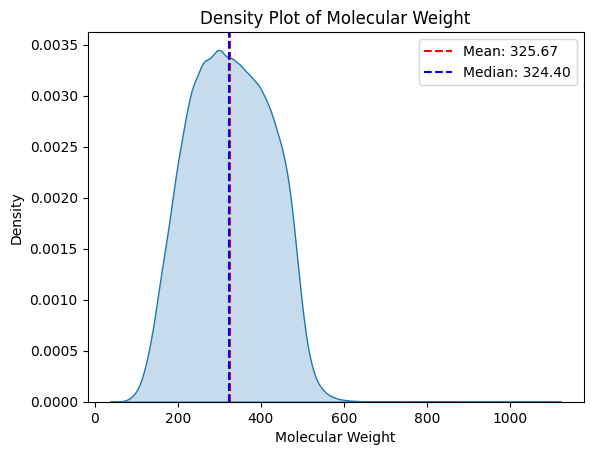

In [9]:
# show a density plot of a specific property, e.g. molecular weight
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(ids_1k_props['mol_weight'], fill=True) # this sets up the plot

# add mean and median lines
mean = ids_1k_props['mol_weight'].mean()
median = ids_1k_props['mol_weight'].median()
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
plt.axvline(median, color='blue', linestyle='--', label=f'Median: {median:.2f}')

# add axis labels and title
plt.xlabel('Molecular Weight')
plt.ylabel('Density')
plt.title('Density Plot of Molecular Weight')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Box and Whisker Plot of Molecular Weight')

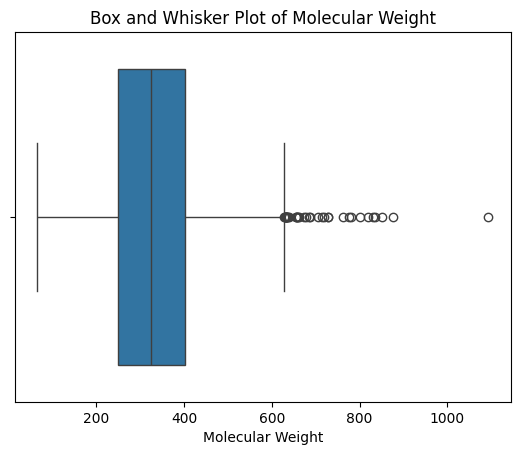

In [10]:
# create a box and whisker plot of the same property
sns.boxplot(x=ids_1k_props['mol_weight'])
plt.xlabel('Molecular Weight')
plt.title('Box and Whisker Plot of Molecular Weight')

In [11]:
zinc250 = pd.read_csv('/Users/jacknugent/Desktop/zinc_250k.csv')

In [12]:
from skimpy import skim
skim(zinc250)

ModuleNotFoundError: No module named 'skimpy'

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

def get_rdkit_props(df, smiles_col):
    """
    df: the pandas dataframe
    smiles_col: the name of the column containing the SMILES strings
    """
    # create a copy of the dataframe to avoid modifying the original
    working_df = df.copy()
    # create empty lists to store the properties
    mol_weights = []
    log_p = []
    ring_counts = []
    rotatable_bonds = []
    tpsa = []
    h_acc = []
    h_donors = []
    labute_asa = []
    mol_mr = []
    
    # loop through the SMILES strings and calculate the properties
    for smi in working_df[smiles_col]: # loop through the SMILES strings
        mol = Chem.MolFromSmiles(smi) # convert the SMILES string to a molecule object
        if mol is None:
            print(f'error making the rdkit object for said smile:{smi}')
        mol_weights.append(Descriptors.MolWt(mol)) # now get the molecular weight
        log_p.append(Descriptors.MolLogP(mol)) # get the logP
        ring_counts.append(Descriptors.RingCount(mol))
        rotatable_bonds.append(Descriptors.NumRotatableBonds(mol))
        tpsa.append(Descriptors.TPSA(mol))
        h_acc.append(Descriptors.NumHAcceptors(mol))
        h_donors.append(Descriptors.NumHDonors(mol))
        labute_asa.append(Descriptors.LabuteASA(mol))
        mol_mr.append(Descriptors.MolMR(mol))


        # add other properties below here

    # add the properties to the dataframe
    working_df['mol_weight'] = mol_weights
    working_df['log_p'] = log_p
    working_df['ring_count'] = ring_counts
    working_df['rotatable_bonds'] = rotatable_bonds
    working_df['tpsa'] = tpsa
    working_df['h_acc'] = h_acc
    working_df['h_donors'] = h_donors
    working_df['labute_asa'] = labute_asa
    working_df['mol_mr'] = mol_mr
    return working_df

# now run this and see what we get
zinc250 = get_rdkit_props(zinc250, 'smiles')
skim(zinc250)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 249455 │ │ float64     │ 8     │                                                          │
│ │ Number of columns │ 13     │ │ int64       │ 4     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column            ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0      ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │       logP        │   0 │     0 │   2.457 │   1.434 │  -6.876 │  1.575 │  2.606 │  3.487 │  8.252 │   ▂█▅  │  │
│ │        qed        │   0 │     0 │  0.7283 │  0.1396 │  0.1118 │ 0.6459 │ 0.7599 │ 0.8357 │ 0.9479 │   ▂▄█▇ │  │
│ │        SAS        │   0 │     0 │   3.053 │  0.8348 │   1.133 │  2.417 │  2.893 │  3.546 │  7.289 │  ▂█▄▁  │  │
│ │    mol_weight     │   0 │     0 │   332.1 │   61.94 │   150.1 │  290.5 │  333.8 │  368.5 │    500 │ ▁▃▆█▃▁ │  │
│ │       log_p       │   0 │     0 │   2.457 │   1.434 │  -6.876 │  1.575 │  2.606 │  3.487 │  8.252 │   ▂█▅  │  │
│ │    ring_count     │   0 │     0 │   2.756 │   1.012 │       0 │      2 │      3 │      3 │      9 │  ▁▅█▁  │  │
│ │  rotatable_bonds  │   0 │     0 │    4.56 │   1.551 │       0 │      3 │      5 │      6 │     11 │   ▄█▅  │  │
│ │       tpsa        │   0 │     0 │   64.82 │   22.93 │       0 │  49.31 │  64.11 │  79.71 │  149.7 │ ▁▅█▅▁  │  │
│ │       h_acc       │   0 │     0 │   3.713 │   1.529 │       0 │      3 │      4 │      5 │     11 │  ▁██▂  │  │
│ │     h_donors      │   0 │     0 │   1.243 │  0.8817 │       0 │      1 │      1 │      2 │      6 │  ▄█▅▁  │  │
│ │    labute_asa     │   0 │     0 │   138.5 │    25.5 │   45.05 │  121.4 │  138.9 │  154.7 │  220.7 │  ▁▆█▃  │  │
│ │      mol_mr       │   0 │     0 │   89.16 │   17.15 │   17.49 │  77.75 │  89.19 │  100.3 │  151.3 │  ▁▆█▂  │  │
│ └───────────────────┴─────┴───────┴─────────┴─────────┴─────────┴────────┴────────┴────────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃        ┃    ┃      ┃           ┃            ┃            ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column ┃ NA ┃ NA % ┃ shortest  ┃ longest    ┃ min        ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ smiles │  0 │    0 │ Cn1nccc1I │ C[C@]12C=C │ BrC#Cc1ccc │ n1onc2c1N │       45.3 │         1 │     249455 │  │
│ │        │    │      │           │ C(=O)C=C1C │    cc1     │ c1nsnc1N2 │            │           │            │  │
│ │        │    │      │           │ C[C@@H]1[C │            │           │            │           │            │  │
│ │        │    │      │           │ @@H]2CC[C@ │       

In [43]:
drug_df = pd.read_csv('/Users/jacknugent/Desktop/drugcentral_structures.smiles.tsv', sep='\t')

In [45]:
drug_df

,SMILES,InChI,InChIKey,ID,INN,CAS_RN
0,CNC(=O)C1=C(C=C(C=C1)C2=NN3C(=CN=C3N=C2)CC4=CC...,InChI=1S/C23H17FN6O/c1-25-22(31)18-6-5-16(11-1...,LIOLIMKSCNQPLV-UHFFFAOYSA-N,5392,capmatinib,1029712-80-8
1,CC(C)(COC1=CN2C(=C(C=N2)C#N)C(=C1)C3=CN=C(C=C3...,"InChI=1S/C29H31N7O3/c1-29(2,37)18-39-24-9-25(2...",XIIOFHFUYBLOLW-UHFFFAOYSA-N,5393,selpercatinib,2152628-33-4
2,CCN1C2=CC(=NC=C2C=C(C1=O)C3=CC(=C(C=C3Br)F)NC(...,InChI=1S/C24H21BrFN5O2/c1-3-31-21-12-22(27-2)2...,CEFJVGZHQAGLHS-UHFFFAOYSA-N,5394,ripretinib,1442472-39-0
3,C[C@]12CC[C@H]3[C@H]([C@@H]1C[C@H]([C@@H]2O)[1...,InChI=1S/C18H23FO2/c1-18-7-6-13-12-5-3-11(20)8...,KDLLNMRYZGUVMA-ZYMZXAKXSA-N,5395,fluoroestradiol F 18,94153-53-4
4,C1=CC2=C(C=C1C3=CN=C(C=C3)[18F])NC4=C2C=NC=C4,InChI=1S/C16H10FN3/c17-16-4-2-11(8-19-16)10-1-...,GETAAWDSFUCLBS-SJPDSGJFSA-N,5396,flortaucipir F 18,1522051-90-6
...,...,...,...,...,...,...
4094,COC(=O)[C@@H]([C@H]1CCCCN1C(=O)OC[N+]2=CC=CC(=...,InChI=1S/C25H29N3O8/c1-35-24(33)21(17-8-3-2-4-...,UBZPNQRBUOBBLN-PWRODBHTSA-N,5448,serdexmethylphenidate,1996626-30-2
4095,C[C@]12CC[C@H]3[C@H]([C@@H]1[C@H]([C@H]([C@@H]...,InChI=1S/C18H24O4/c1-18-7-6-12-11-5-3-10(19)8-...,AJIPIJNNOJSSQC-NYLIRDPKSA-N,5450,estetrol,15183-37-6
4096,OC(=O)CC[C@H](NC(=O)N[C@@H](CCCCNC(=O)C1=C...,NaN,NaN,5458,piflufolastat F-18,1207181-29-0
4097,CCN1CCN(CC1)C2=CC=C(C=C2)NC3=CC(=NC=N3)N(C)C(=...,InChI=1S/C26H31Cl2N7O3/c1-5-34-10-12-35(13-11-...,QADPYRIHXKWUSV-UHFFFAOYSA-N,5459,infigratinib,872511-34-7


In [46]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

def get_rdkit_props(df, smiles_col):
    """
    df: the pandas dataframe
    smiles_col: the name of the column containing the SMILES strings
    """
    # create a copy of the dataframe to avoid modifying the original
    working_df = df.copy()
    # create empty lists to store the properties
    mol_weights = []
    log_p = []
    ring_counts = []
    rotatable_bonds = []
    tpsa = []
    h_acc = []
    h_donors = []
    labute_asa = []
    mol_mr = []
    
    # loop through the SMILES strings and calculate the properties
    for smi in working_df[smiles_col]: # loop through the SMILES strings
        mol = Chem.MolFromSmiles(smi) # convert the SMILES string to a molecule object
        if mol is None:
            print(f'error making the rdkit object for said smile:{smi}')
        mol_weights.append(Descriptors.MolWt(mol)) # now get the molecular weight
        log_p.append(Descriptors.MolLogP(mol)) # get the logP
        ring_counts.append(Descriptors.RingCount(mol))
        rotatable_bonds.append(Descriptors.NumRotatableBonds(mol))
        tpsa.append(Descriptors.TPSA(mol))
        h_acc.append(Descriptors.NumHAcceptors(mol))
        h_donors.append(Descriptors.NumHDonors(mol))
        labute_asa.append(Descriptors.LabuteASA(mol))
        mol_mr.append(Descriptors.MolMR(mol))


        # add other properties below here

    # add the properties to the dataframe
    working_df['mol_weight'] = mol_weights
    working_df['log_p'] = log_p
    working_df['ring_count'] = ring_counts
    working_df['rotatable_bonds'] = rotatable_bonds
    working_df['tpsa'] = tpsa
    working_df['h_acc'] = h_acc
    working_df['h_donors'] = h_donors
    working_df['labute_asa'] = labute_asa
    working_df['mol_mr'] = mol_mr
    return working_df

# now run this and see what we get
drug_df = get_rdkit_props(drug_df, 'SMILES')


[09:59:12] WARNING: not removing hydrogen atom without neighbors


In [ ]:
rows_with_any_none = zinc250[zinc250.isna().any(axis=1)]
rows_with_any_none


,smiles,logP,qed,SAS,mol_weight,log_p,ring_count,rotatable_bonds,tpsa,h_acc,h_donors,labute_asa,mol_mr


In [ ]:
rows_with_any_none = drug_df[drug_df.isna().any(axis=1)]
rows_with_any_none


,smiles,logP,qed,SAS,mol_weight,log_p,ring_count,rotatable_bonds,tpsa,h_acc,h_donors,labute_asa,mol_mr


In [ ]:
import requests, time

cas_df = pd.read_csv('/Users/jacknugent/Desktop/tri_cas_numbers.csv')

smiles_list= []

for cas in cas_df['cas']:
    url = ("https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/"+
    f"{str(cas)}/property/CanonicalSMILES/JSON")
    r = requests.get(url)
    smiles = None
    if r.status_code != 200:
        print(f' failed cuz of:{r.status_code}, compound cas:{cas}, url:{url}')
    else:
        props = (
            r.json()
            .get("PropertyTable", {})
            .get("Properties", [])
        )

        if props:
            smiles = (
                props[0].get("CanonicalSMILES")
                or props[0].get("ConnectivitySMILES")
            )
        
    smiles_list.append(smiles)
    time.sleep(0.05)

cas_df['smiles'] = smiles_list
    


 failed cuz of:404, compound cas:1078142-10-5, url:https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/1078142-10-5/property/CanonicalSMILES/JSON
 failed cuz of:404, compound cas:1078712-88-5, url:https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/1078712-88-5/property/CanonicalSMILES/JSON
 failed cuz of:404, compound cas:1078715-61-3, url:https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/1078715-61-3/property/CanonicalSMILES/JSON
 failed cuz of:404, compound cas:118400-71-8, url:https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/118400-71-8/property/CanonicalSMILES/JSON
 failed cuz of:404, compound cas:123171-68-6, url:https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/123171-68-6/property/CanonicalSMILES/JSON
 failed cuz of:404, compound cas:125476-71-3, url:https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/125476-71-3/property/CanonicalSMILES/JSON
 failed cuz of:404, compound cas:1319-77-3, url:https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/13

In [ ]:
skim(cas_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 822    │ │ string      │ 2     │                                                          │
│ │ Number of columns │ 2      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃        ┃    ┃           ┃          ┃           ┃           ┃         ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column ┃ NA ┃ NA %      ┃ shortest ┃ longest   ┃ min       ┃ max     ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━╇━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │  cas   │  0 │         0 │ 50-00-0  │ 1078142-1 │ 100-01-6  │ 99-65-0 │       8.62 │         1 │        822 │  │
│ │        │    │           │          │    0-5    │           │         │            │           │            │  │
│ │ smiles │ 84 │ 10.218978 │    F     │ CCC(C)C1C │ B(Cl)(Cl) │  [Zn]   │         34 │       0.9 │        738 │  │
│ │        │    │ 102189782 │          │ (C=CC2(O1 │    Cl     │         │            │           │            │  │
│ │        │    │           │          │ )CC3CC(O2 │           │         │            │           │            │  │
│ │        │    │           │          │ )CC=C(C(C │           │         │            │           │            │  │
│ │        │    │           │          │ (C=CC=C4C │           │         │            │           │            │  │
│ │        │    │           │          │ OC5C4(C(C │           │         │            │           │            │  │
│ │        │    │           │          │ =C(C5O)C) │           │         │            │           │            │  │
│ │        │    │           │          │ C(=O)O3)O │           │         │            │           │            │  │
│ │        │    │           │          │ )C)OC6CC( │           │         │            │           │            │  │
│ │        │    │           │          │ C(C(O6)C) │           │         │            │           │            │  │
│ │        │    │           │          │ OC7CC(C(C │           │         │            │           │            │  │
│ │        │    │           │          │ (O7)C)O)O │           │         │            │           │            │  │
│ │        │    │           │          │ C)OC)C)C. │           │         │            │           │            │  │
│ │        │    │           │          │ CC1C=CC=C │           │         │            │           │            │  │
│ │        │    │           │          │ 2COC3C2(C │           │         │            │           │            │  │
│ │        │    │           │          │ (C=C(C3O) │           │         │            │           │            │  │
│ │        │    │           │          │ C)C(=O)OC │           │         │            │           │            │  │
│ │        │    │           │          │ 4CC(CC=C( │           │         │            │           │            │  │
│ │        │    │           │          │ C1OC5CC(C │           │         │            │           │            │  │
│ │        │    │           │          │ (C(O5)C)O │    

In [ ]:
tri_df = cas_df 

def get_rdkit_props(df, smiles_col):
    """
    df: the pandas dataframe
    smiles_col: the name of the column containing the SMILES strings
    """
    # create a copy of the dataframe to avoid modifying the original
    working_df = df.copy()
    # create empty lists to store the properties
    mol_weights = []
    log_p = []
    ring_counts = []
    rotatable_bonds = []
    tpsa = []
    h_acc = []
    h_donors = []
    labute_asa = []
    mol_mr = []
    
    # loop through the SMILES strings and calculate the properties
    for smi in working_df[smiles_col]:
        if smi: # loop through the SMILES strings
            mol = Chem.MolFromSmiles(str(smi)) # convert the SMILES string to a molecule object
            if mol is None:
                print(f'error making the rdkit object for said smile:{smi}')
                mol_weights.append(None)
                log_p.append(None)
                ring_counts.append(None)
                rotatable_bonds.append(None)
                tpsa.append(None)
                h_acc.append(None)
                h_donors.append(None)
                labute_asa.append(None)
                mol_mr.append(None)
            else:
                mol_weights.append(Descriptors.MolWt(mol)) # now get the molecular weight
                log_p.append(Descriptors.MolLogP(mol)) # get the logP
                ring_counts.append(Descriptors.RingCount(mol))
                rotatable_bonds.append(Descriptors.NumRotatableBonds(mol))
                tpsa.append(Descriptors.TPSA(mol))
                h_acc.append(Descriptors.NumHAcceptors(mol))
                h_donors.append(Descriptors.NumHDonors(mol))
                labute_asa.append(Descriptors.LabuteASA(mol))
                mol_mr.append(Descriptors.MolMR(mol))
        else:
            mol_weights.append(None)
            log_p.append(None)
            ring_counts.append(None)
            rotatable_bonds.append(None)
            tpsa.append(None)
            h_acc.append(None)
            h_donors.append(None)
            labute_asa.append(None)
            mol_mr.append(None)

        # add other properties below here

    # add the properties to the dataframe
    working_df['mol_weight'] = mol_weights
    working_df['log_p'] = log_p
    working_df['ring_count'] = ring_counts
    working_df['rotatable_bonds'] = rotatable_bonds
    working_df['tpsa'] = tpsa
    working_df['h_acc'] = h_acc
    working_df['h_donors'] = h_donors
    working_df['labute_asa'] = labute_asa
    working_df['mol_mr'] = mol_mr
    return working_df

# now run this and see what we get
tri_df = get_rdkit_props(tri_df, 'smiles')
skim(tri_df)

error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdkit object for said smile:nan
error making the rdk

[15:57:42] SMILES Parse Error: syntax error while parsing: nan
[15:57:42] SMILES Parse Error: check for mistakes around position 2:
[15:57:42] nan
[15:57:42] ~^
[15:57:42] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:57:42] SMILES Parse Error: syntax error while parsing: nan
[15:57:42] SMILES Parse Error: check for mistakes around position 2:
[15:57:42] nan
[15:57:42] ~^
[15:57:42] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:57:42] SMILES Parse Error: syntax error while parsing: nan
[15:57:42] SMILES Parse Error: check for mistakes around position 2:
[15:57:42] nan
[15:57:42] ~^
[15:57:42] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:57:42] SMILES Parse Error: syntax error while parsing: nan
[15:57:42] SMILES Parse Error: check for mistakes around position 2:
[15:57:42] nan
[15:57:42] ~^
[15:57:42] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:57:42] SMILES Parse Error: syntax error while pa

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 822    │ │ float64     │ 9     │                                                          │
│ │ Number of columns │ 11     │ │ string      │ 2     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column          ┃ NA ┃ NA %           ┃ mean   ┃ sd     ┃ p0     ┃ p25    ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │   mol_weight    │ 84 │ 10.21897810218 │  262.8 │  204.2 │  9.012 │  120.4 │ 203.1 │ 337.6 │  1732 │  █▃▁   │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ │      log_p      │ 84 │ 10.21897810218 │  2.264 │  2.825 │ -14.45 │ 0.7653 │  2.08 │ 3.572 │ 17.23 │   ▄█▁  │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ │   ring_count    │ 84 │ 10.21897810218 │ 0.8672 │   1.32 │      0 │      0 │     0 │     1 │    14 │   █▁   │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ │ rotatable_bonds │ 84 │ 10.21897810218 │  3.267 │  4.024 │      0 │      0 │     2 │     5 │    20 │  █▂▁▁  │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ │      tpsa       │ 84 │ 10.21897810218 │   40.7 │  43.74 │      0 │  12.03 │ 35.53 │ 57.19 │ 411.2 │   █▁   │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ │      h_acc      │ 84 │ 10.21897810218 │  2.335 │  2.499 │      0 │      1 │     2 │     3 │    28 │   █▁   │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ │    h_donors     │ 84 │ 10.21897810218 │ 0.5705 │ 0.9296 │      0 │      0 │     0 │     1 │     6 │  █▃▁   │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ │   labute_asa    │ 84 │ 10.21897810218 │  96.35 │  70.91 │  6.097 │  46.01 │  81.7 │ 130.8 │ 726.4 │   █▃   │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ │     mol_mr      │ 84 │ 10.21897810218 │  51.59 │  37.52 │      0 │  25.98 │ 45.72 │ 71.26 │   450 │   █▂   │  │
│ │                 │    │           9782 │        │        │        │        │       │       │       │        │  │
│ └─────────────────┴────┴────────────────┴────────┴────────┴────────┴────────┴───────┴───────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃        ┃    ┃           ┃          ┃           ┃           ┃         ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column ┃ NA ┃ NA %      ┃ shortest ┃ longest   ┃ min

In [ ]:
ids_1k_props = ids_1k_props.reset_index(drop=True)
skim(ids_1k_props)


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 99999  │ │ float64     │ 5     │                                                          │
│ │ Number of columns │ 11     │ │ int64       │ 4     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %  ┃ mean   ┃ sd      ┃ p0      ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │     mol_weight     │   0 │     0 │  325.7 │   96.24 │    66.1 │  250.3 │  324.4 │  401.5 │   1093 │  ▃█▃   │  │
│ │       log_p        │   0 │     0 │  3.161 │    1.59 │  -6.652 │  2.096 │  3.135 │    4.2 │  12.11 │   ▆█▁  │  │
│ │     ring_count     │   0 │     0 │  2.625 │   1.274 │       0 │      2 │      3 │      4 │     12 │  ▃█▄   │  │
│ │  rotatable_bonds   │   0 │     0 │  4.214 │   2.592 │       0 │      2 │      4 │      6 │     27 │  █▅▁   │  │
│ │        tpsa        │   0 │     0 │  61.71 │   28.43 │       0 │  41.57 │   59.3 │  79.55 │  262.4 │  ▄█▂   │  │
│ │       h_acc        │   0 │     0 │   3.86 │   1.722 │       0 │      3 │      4 │      5 │     15 │  ▄█▅   │  │
│ │      h_donors      │   0 │     0 │  1.047 │  0.9721 │       0 │      0 │      1 │      2 │     11 │   █▃   │  │
│ │     labute_asa     │   0 │     0 │    134 │   39.48 │   31.25 │  102.2 │  133.5 │  166.2 │  273.3 │ ▁▇█▇▂  │  │
│ │       mol_mr       │   0 │     0 │  86.16 │   26.16 │   18.59 │   65.2 │   85.9 │    107 │  165.6 │ ▁▆█▇▄  │  │
│ └────────────────────┴─────┴───────┴────────┴─────────┴─────────┴────────┴────────┴────────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃           ┃           ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min       ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │  smiles   │  0 │    0 │  CCCCOC  │ CCN1C[C@] │ Br/C=C/CC │ c1scc2[nH │       39.3 │         1 │      99999 │  │
│ │           │    │      │          │ 2(COC)[C@ │    Br     │ ]c(CNC34C │            │           │            │  │
│ │           │    │      │          │ H](O)C[C@ │           │ C5CC(CC(C │            │           │            │  │
│ │           │    │      │          │ H](OC)[C@ │           │ 5)C3)C4)n │            │           │            │  │
│ │           │    │      │          │ ]34C1[C@H │           │    c12    │            │           │            │  │
│ │           │    │      │          │ ]([C@H](O │           │           │            │           │            │  │
│ │           │    │      │          │ C)[C@H]23 │      

In [47]:
ids_1k_props.to_pickle('/Users/jacknugent/Downloads/ids_100k_props.pkl')
tri_df.to_pickle('/Users/jacknugent/Downloads/tri_props.pkl')
drug_df.to_pickle('/Users/jacknugent/Downloads/drug_dfdf.pkl')
zinc250.to_pickle('/Users/jacknugent/Downloads/zinc250.pkl')


In [2]:
import pandas as pd

In [3]:
ids_1k_props = pd.read_pickle('/Users/jacknugent/Downloads/ids_100k_props.pkl')
tri_df = pd.read_pickle('/Users/jacknugent/Downloads/tri_props.pkl')
zinc250 = pd.read_pickle('/Users/jacknugent/Downloads/zinc250.pkl')
drug_df = pd.read_pickle('/Users/jacknugent/Downloads/drug_dfdf.pkl')

In [ ]:
'''
Plots below are created by Claude Opus 4.8 (also debugging help)

Comments are from me (Jack Nugent)!

I plan to rewrite everything once I have time too
'''

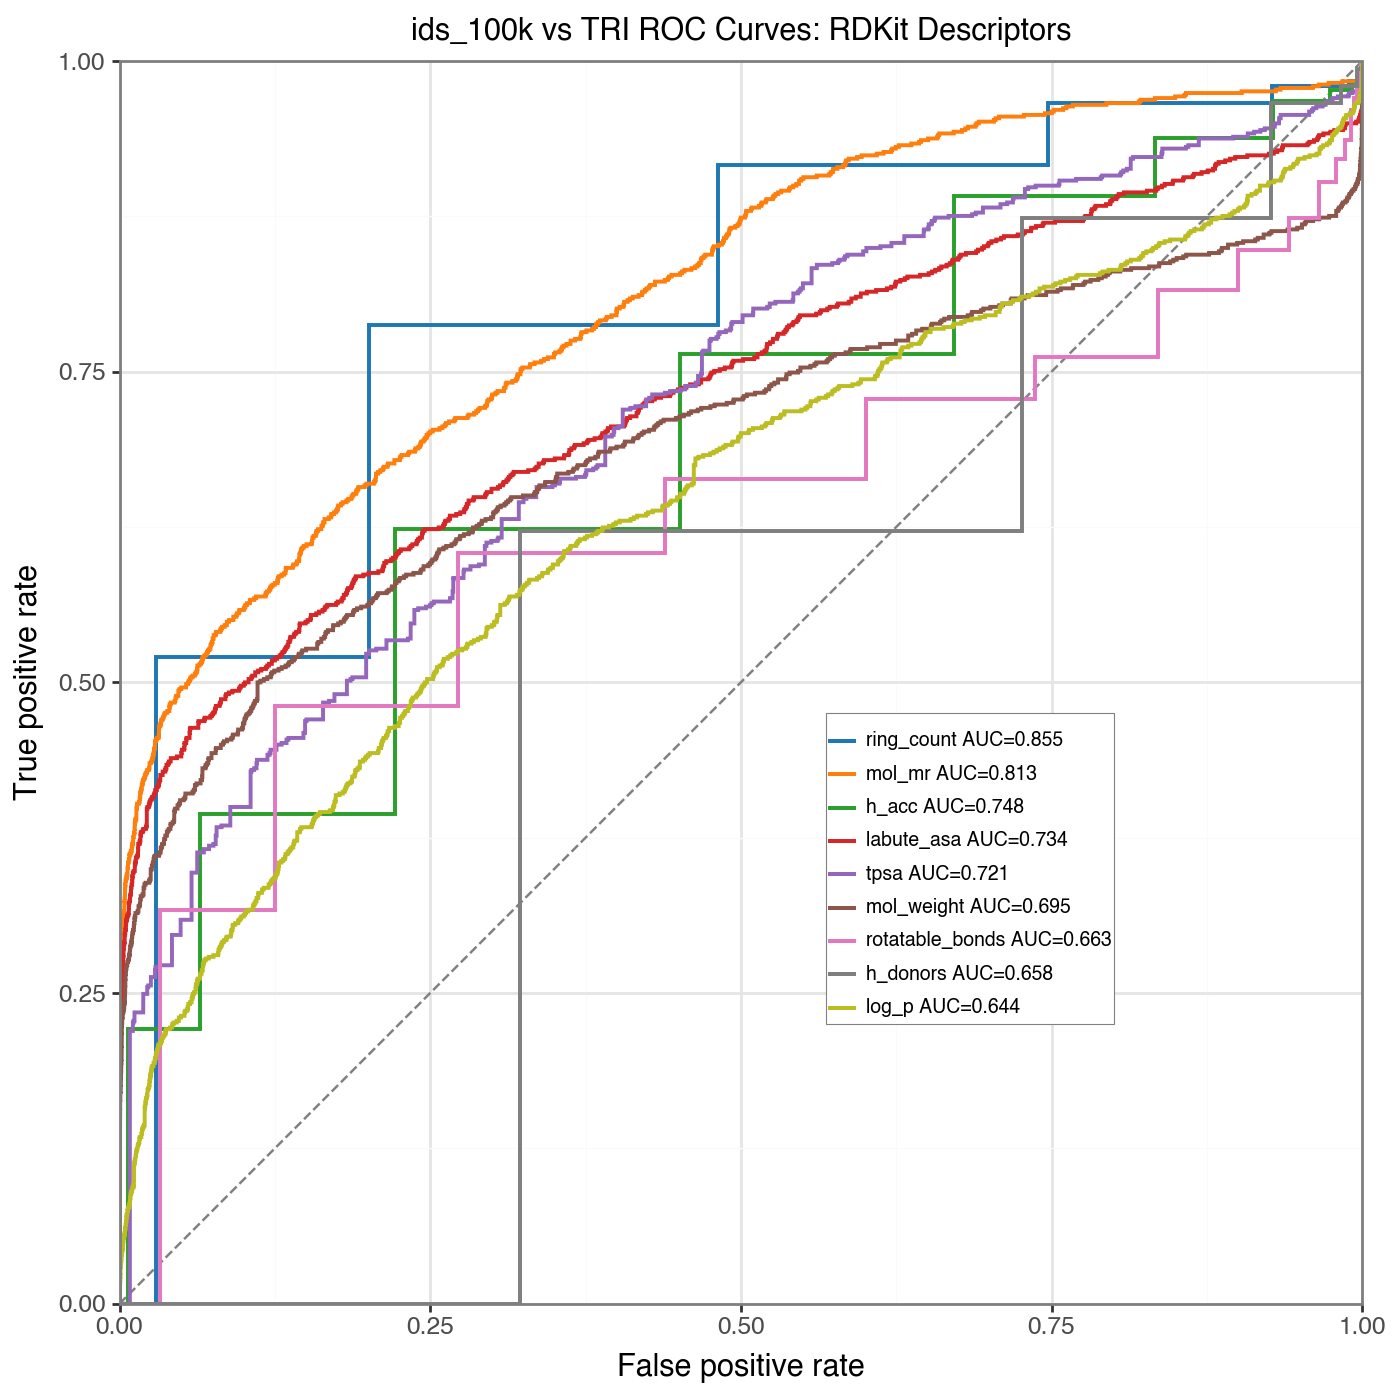

In [3]:
# import packages
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
from plotnine import (ggplot, aes, geom_step, geom_abline, labs, theme_bw, theme,
                      coord_fixed, scale_color_manual, scale_x_continuous,
                      scale_y_continuous, element_text, element_rect)


# our descriptors / features
descriptors = [
    'ring_count',
    'mol_mr',
    'h_acc',
    'labute_asa',
    'tpsa',
    'mol_weight',
    'rotatable_bonds',
    'h_donors',
    'log_p',
]

# make one big dataset from the two and assign a label 1 or 0 for origin dataset
both = pd.concat([
    ids_1k_props.assign(label=0)[descriptors + ['label']],
    tri_df.assign(label=1)[descriptors + ['label']],
], ignore_index=True)

# we need to shift this dataset long 
curves = []
for col in descriptors:
    d = both[[col, 'label']].dropna()
    score = d[col].to_numpy(dtype=float)
    auc = roc_auc_score(d['label'], score)
    if auc < 0.5:     # make sure that if its good at classifying for other dataset then it doesnt give low auc values instead
        score, auc = -score, 1 - auc
    fpr, tpr, _ = roc_curve(d['label'], score)
    curves.append(pd.DataFrame({'fpr': fpr, 'tpr': tpr,
                                'descriptor': f'{col} AUC={auc:.3f}', 'auc': auc}))

roc_df = pd.concat(curves, ignore_index=True)

# order the legend by AUC (highest first)
order = roc_df.groupby('descriptor')['auc'].first().sort_values(ascending=False).index.tolist()
roc_df['descriptor'] = pd.Categorical(roc_df['descriptor'], categories=order, ordered=True)

# pretty colors
tab10 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
colors = dict(zip(order, tab10))


#now plot
(
    ggplot(roc_df, aes('fpr', 'tpr', color='descriptor'))
    + geom_abline(slope=1, intercept=0, linetype='dashed', color='grey')
    + geom_step(size=0.8)
    + scale_color_manual(values=colors)
    + scale_x_continuous(limits=(0, 1), expand=(0, 0)) #set scales
    + scale_y_continuous(limits=(0, 1), expand=(0, 0))
    + coord_fixed()
    + labs(x='False positive rate', y='True positive rate', #titles and labels and stuff
           title='ids_100k vs TRI ROC Curves: RDKit Descriptors', color='')
    + theme_bw()
    + theme( #theme stuff
        figure_size=(7, 7),
        plot_title=element_text(size=11, ha='center'),
        legend_position=(0.74, 0.30),
        legend_title=element_text(size=0),
        legend_text=element_text(size=7),
        legend_key_size=10,
        legend_background=element_rect(fill='white', color='grey', size=0.4),
    )
)

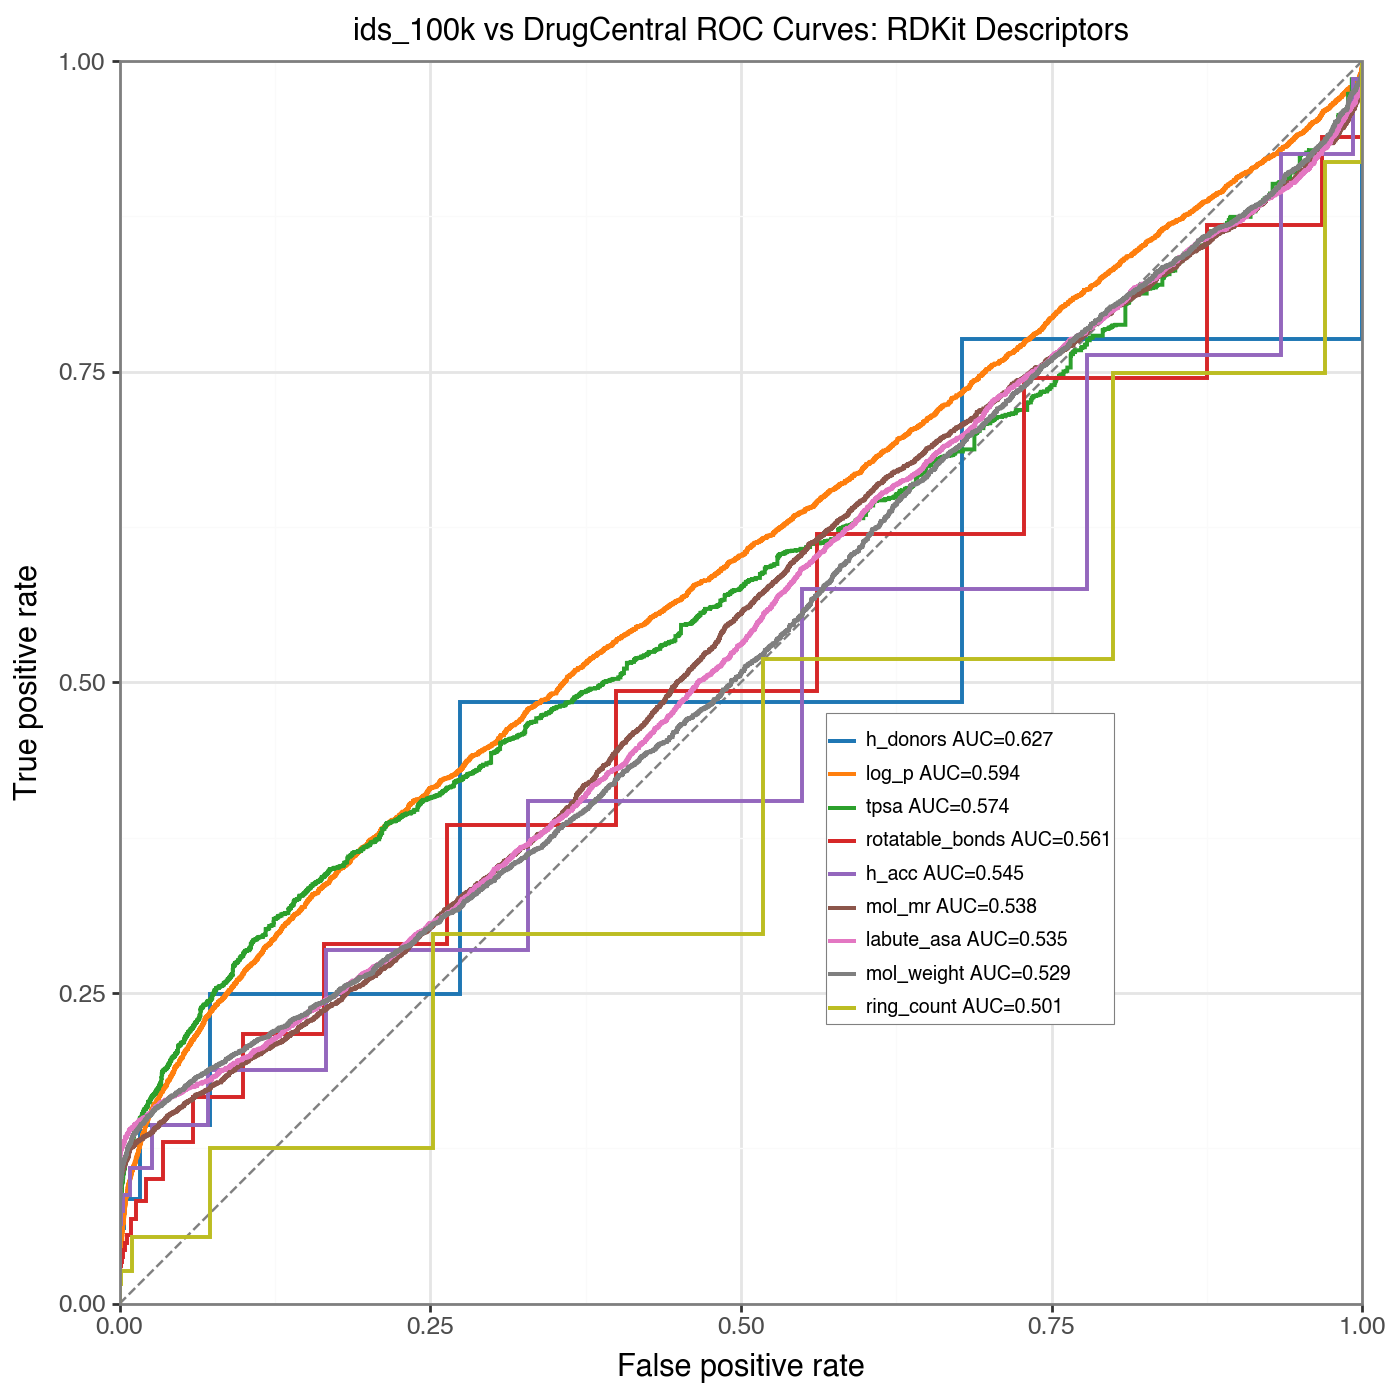

In [4]:
# packages
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
from plotnine import (ggplot, aes, geom_step, geom_abline, labs, theme_bw, theme,
                      coord_fixed, scale_color_manual, scale_x_continuous,
                      scale_y_continuous, element_text, element_rect)


# descriptors / features
descriptors = [
    'ring_count',
    'mol_mr',
    'h_acc',
    'labute_asa',
    'tpsa',
    'mol_weight',
    'rotatable_bonds',
    'h_donors',
    'log_p',
]

# stack the two datasets and add label 1 or 0 for the dataset it came from
both = pd.concat([
    ids_1k_props.assign(label=0)[descriptors + ['label']],
    drug_df.assign(label=1)[descriptors + ['label']],
], ignore_index=True)

# build a long dataframe of ROC points, one descriptor at a time
curves = []
for col in descriptors:
    d = both[[col, 'label']].dropna()
    score = d[col].to_numpy(dtype=float)
    auc = roc_auc_score(d['label'], score)
    if auc < 0.5:        # flip all of the curves the same way to get a better sense of accuracy in prediction
        score, auc = -score, 1 - auc
    fpr, tpr, _ = roc_curve(d['label'], score)
    curves.append(pd.DataFrame({'fpr': fpr, 'tpr': tpr,
                                'descriptor': f'{col} AUC={auc:.3f}', 'auc': auc}))

# add up all the curves
roc_df = pd.concat(curves, ignore_index=True)

# sort by auc so highest first
order = roc_df.groupby('descriptor')['auc'].first().sort_values(ascending=False).index.tolist()
roc_df['descriptor'] = pd.Categorical(roc_df['descriptor'], categories=order, ordered=True)

# pretty colors for the lines
tab10 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
colors = dict(zip(order, tab10))

#plot
(
    ggplot(roc_df, aes('fpr', 'tpr', color='descriptor'))
    + geom_abline(slope=1, intercept=0, linetype='dashed', color='grey')
    + geom_step(size=0.8)
    + scale_color_manual(values=colors)
    + scale_x_continuous(limits=(0, 1), expand=(0, 0))
    + scale_y_continuous(limits=(0, 1), expand=(0, 0))
    + coord_fixed()
    + labs(x='False positive rate', y='True positive rate',
           title='ids_100k vs DrugCentral ROC Curves: RDKit Descriptors', color='')
    + theme_bw()
    + theme(
        figure_size=(7, 7),
        plot_title=element_text(size=11, ha='center'),
        legend_position=(0.74, 0.30),
        legend_title=element_text(size=0),
        legend_text=element_text(size=7),
        legend_key_size=10,
        legend_background=element_rect(fill='white', color='grey', size=0.4),
    )
)

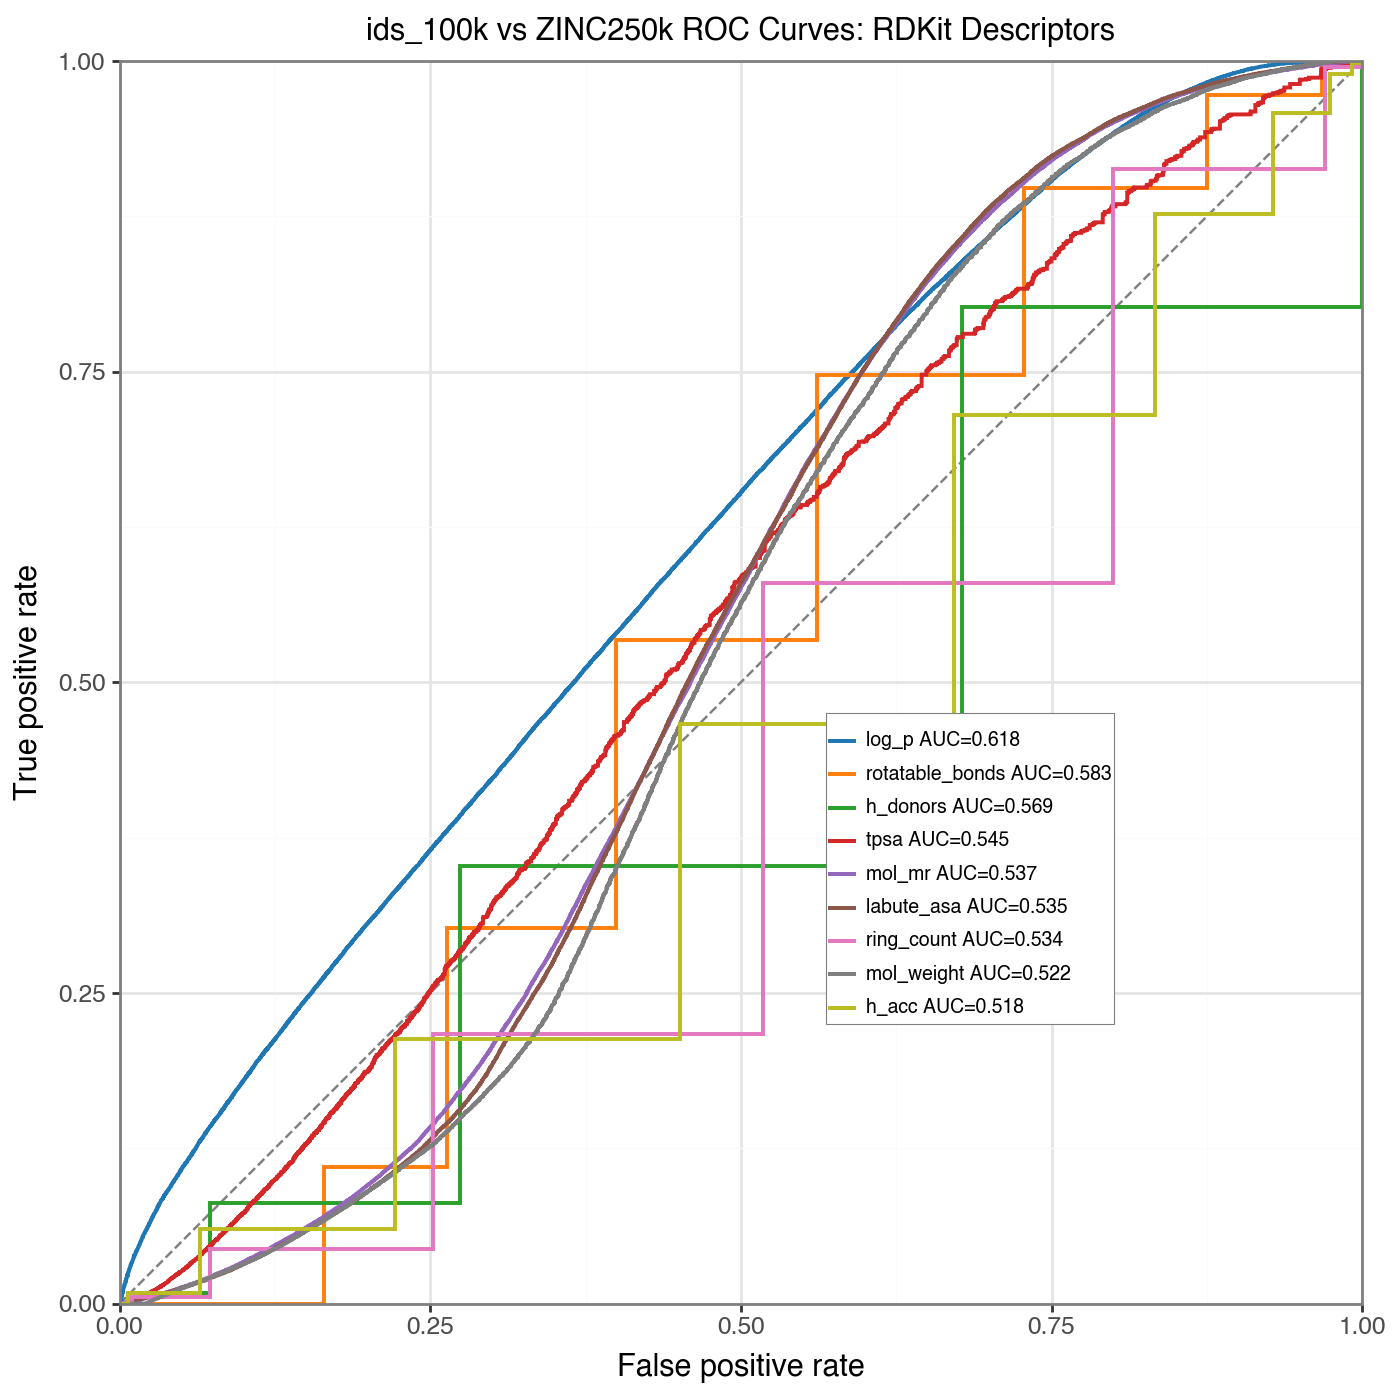

In [5]:
# ROC curves: how well does each descriptor separate ZINC250k from our ids_100k dataset?
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
from plotnine import (ggplot, aes, geom_step, geom_abline, labs, theme_bw, theme,
                      coord_fixed, scale_color_manual, scale_x_continuous,
                      scale_y_continuous, element_text, element_rect)

descriptors = [
    'ring_count',
    'mol_mr',
    'h_acc',
    'labute_asa',
    'tpsa',
    'mol_weight',
    'rotatable_bonds',
    'h_donors',
    'log_p',
]

# stack the two datasets: ZINC250k = 1, ids_100k = 0
both = pd.concat([
    ids_1k_props.assign(label=0)[descriptors + ['label']],
    zinc250.assign(label=1)[descriptors + ['label']],
], ignore_index=True)

# build a long dataframe of ROC points, one descriptor at a time
curves = []
for col in descriptors:
    d = both[[col, 'label']].dropna()
    score = d[col].to_numpy(dtype=float)
    auc = roc_auc_score(d['label'], score)
    if auc < 0.5:                       # orient so every curve bows upward (AUC >= 0.5)
        score, auc = -score, 1 - auc
    fpr, tpr, _ = roc_curve(d['label'], score)
    curves.append(pd.DataFrame({'fpr': fpr, 'tpr': tpr,
                                'descriptor': f'{col} AUC={auc:.3f}', 'auc': auc}))

roc_df = pd.concat(curves, ignore_index=True)

# order the legend by AUC (highest first)
order = roc_df.groupby('descriptor')['auc'].first().sort_values(ascending=False).index.tolist()
roc_df['descriptor'] = pd.Categorical(roc_df['descriptor'], categories=order, ordered=True)

# matplotlib tab10 palette, assigned in AUC order
tab10 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
colors = dict(zip(order, tab10))

# plot using plotnine
(
    ggplot(roc_df, aes('fpr', 'tpr', color='descriptor'))
    + geom_abline(slope=1, intercept=0, linetype='dashed', color='grey')
    + geom_step(size=0.8)
    + scale_color_manual(values=colors)
    + scale_x_continuous(limits=(0, 1), expand=(0, 0))
    + scale_y_continuous(limits=(0, 1), expand=(0, 0))
    + coord_fixed()
    + labs(x='False positive rate', y='True positive rate',
           title='ids_100k vs ZINC250k ROC Curves: RDKit Descriptors', color='')
    + theme_bw()
    + theme(
        figure_size=(7, 7),
        plot_title=element_text(size=11, ha='center'),
        legend_position=(0.74, 0.30),
        legend_title=element_text(size=0),
        legend_text=element_text(size=7),
        legend_key_size=10,
        legend_background=element_rect(fill='white', color='grey', size=0.4),
    )
)

Training AUC: 0.904
Test AUC:     0.929

Decision tree rules:
|--- ring_count <= 1.50
|   |--- mol_mr <= 43.59
|   |   |--- class: 1
|   |--- mol_mr >  43.59
|   |   |--- class: 1
|--- ring_count >  1.50
|   |--- rotatable_bonds <= 2.50
|   |   |--- class: 1
|   |--- rotatable_bonds >  2.50
|   |   |--- class: 0



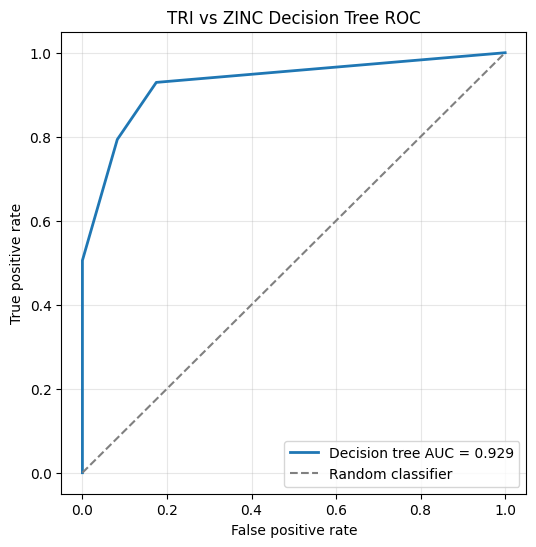

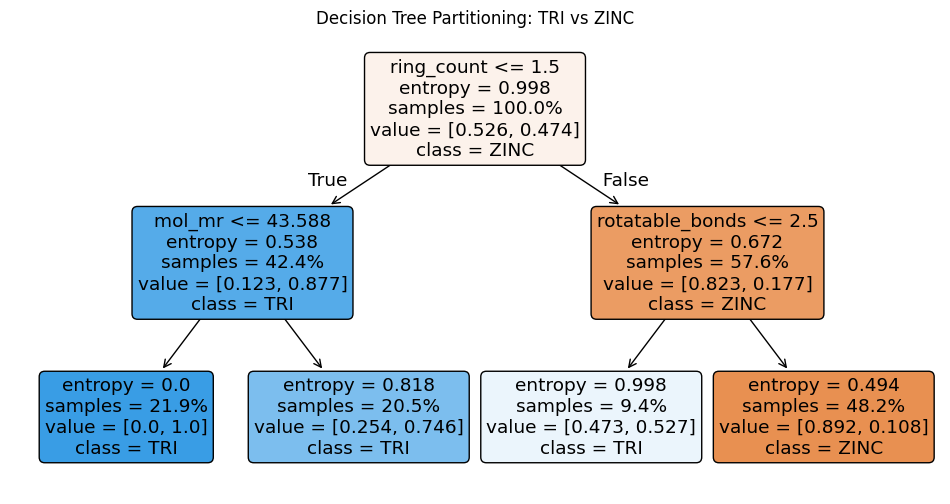

In [6]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

# descriptors 
descriptor_cols = [
    'mol_weight',
    'log_p',
    'ring_count',
    'rotatable_bonds',
    'tpsa',
    'h_acc',
    'h_donors',
    'labute_asa',
    'mol_mr',
]

# making these datasets tidy and adding the kind of dataset so when we merge them we can see where they came from
tri_model = tri_df[descriptor_cols].copy()
tri_model['dataset'] = 'TRI'

zinc_model = zinc250[descriptor_cols].copy()
zinc_model['dataset'] = 'ZINC'

# make sure both are same size so model cannot get better by favoring dataset over the other
n = min(len(tri_model), len(zinc_model))
tri_model = tri_model.sample(n=n, random_state=0)
zinc_model = zinc_model.sample(n=n, random_state=0)

#combine the datasets
model_df = pd.concat([tri_model, zinc_model], ignore_index=True).dropna()

#Create x and y for training
X = model_df[descriptor_cols]
y = (model_df['dataset'] == 'TRI').astype(int)   # gives a value of 1 if tri and 0 if not cuz turns True or False into int 1 or 0

# scikit learn train test split 25% test
# test dataset needed to get true accuracy 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

# init tree scikit learn
tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=2,          # gives a compact tree like the paper figure
    min_samples_leaf=25,  # avoids tiny, overly specific leaves
    random_state=0
)
# fit!
tree.fit(X_train, y_train)

# Get train and test accuracy

train_scores = tree.predict_proba(X_train)[:, 1]
test_scores = tree.predict_proba(X_test)[:, 1]

#train and test auc
train_auc = roc_auc_score(y_train, train_scores)
test_auc = roc_auc_score(y_test, test_scores)

print(f"Training AUC: {train_auc:.3f}")
print(f"Test AUC:     {test_auc:.3f}")

print("\nDecision tree rules:")
print(export_text(tree, feature_names=descriptor_cols))

# create roc curve for plotting
fpr, tpr, thresholds = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Decision tree AUC = {test_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('TRI vs ZINC Decision Tree ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Show the tree scikit learn makes this easy
plt.figure(figsize=(12, 6))
plot_tree(
    tree,
    feature_names=descriptor_cols,
    class_names=['ZINC', 'TRI'],
    filled=True,
    rounded=True,
    proportion=True
)
plt.title('Decision Tree Partitioning: TRI vs ZINC')
plt.show()

In [7]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

#descriptors / features
descriptor_cols = [
    'mol_weight',
    'log_p',
    'ring_count',
    'rotatable_bonds',
    'tpsa',
    'h_acc',
    'h_donors',
    'labute_asa',
    'mol_mr',
]

def run_partition_model(df_a, df_b, label_a, label_b, title, random_state=0):
    """
    df_a, df_b: dataframes with descriptor columns
    label_a, label_b: class names, e.g. 'TRI' and 'ZINC'
    random state helps for reproducability
    """
    # clean up datasets keeping only our columns and add where the dataset is from
    a = df_a[descriptor_cols].copy()
    a['dataset'] = label_a

    b = df_b[descriptor_cols].copy()
    b['dataset'] = label_b

    # balance classes so the tree does not just learn the bigger dataset
    # for exampe if dataset a is 3x bigger than model will have good accuracy just picking that one every time
    n = min(len(a), len(b))
    a = a.sample(n=n, random_state=random_state)
    b = b.sample(n=n, random_state=random_state)

    # merge datasets
    model_df = pd.concat([a, b], ignore_index=True).dropna()

    X = model_df[descriptor_cols]
    y = (model_df['dataset'] == label_a).astype(int)   # dataset a  = 1, dataset b = 0

    # train test split 25% test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )

    # init tree scikit learn makes this easy
    tree = DecisionTreeClassifier(
        criterion='entropy', #shannon entropy as loss, remember that 90% 10% classification is less uncertain than 50 50 
        max_depth=2, # only three classifiers like in the paper
        min_samples_leaf=25, 
        random_state=random_state 
    )

    #fit
    tree.fit(X_train, y_train)

    # give train and test scores as well as train and test auc
    train_scores = tree.predict_proba(X_train)[:, 1]
    test_scores = tree.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_scores)
    test_auc = roc_auc_score(y_test, test_scores)

    print(f"\n=== {title} ===")
    print(f"Samples per class: {n}")
    print(f"Training AUC: {train_auc:.3f}")
    print(f"Test AUC:     {test_auc:.3f}")
    print("\nDecision tree rules:")
    # sci kit learn lets us show the tree very nicely like this
    print(export_text(tree, feature_names=descriptor_cols))

    # show a roc curve 
    fpr, tpr, _ = roc_curve(y_test, test_scores)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(fpr, tpr, linewidth=2, label=f'Test AUC = {test_auc:.3f}')
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    axes[0].set_xlabel('False positive rate')
    axes[0].set_ylabel('True positive rate')
    axes[0].set_title(f'{title} ROC')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # plot tree scikit learn makes it easy
    plot_tree(
        tree,
        feature_names=descriptor_cols,
        class_names=[label_b, label_a],
        filled=True,
        rounded=True,
        proportion=True,
        ax=axes[1]
    )
    axes[1].set_title(f'{title} Decision Tree')

    plt.tight_layout()
    plt.show()

    return tree, test_auc


=== ids_100k vs ZINC ===
Samples per class: 99999
Training AUC: 0.637
Test AUC:     0.637

Decision tree rules:
|--- rotatable_bonds <= 7.50
|   |--- labute_asa <= 101.11
|   |   |--- class: 1
|   |--- labute_asa >  101.11
|   |   |--- class: 0
|--- rotatable_bonds >  7.50
|   |--- labute_asa <= 137.98
|   |   |--- class: 1
|   |--- labute_asa >  137.98
|   |   |--- class: 1



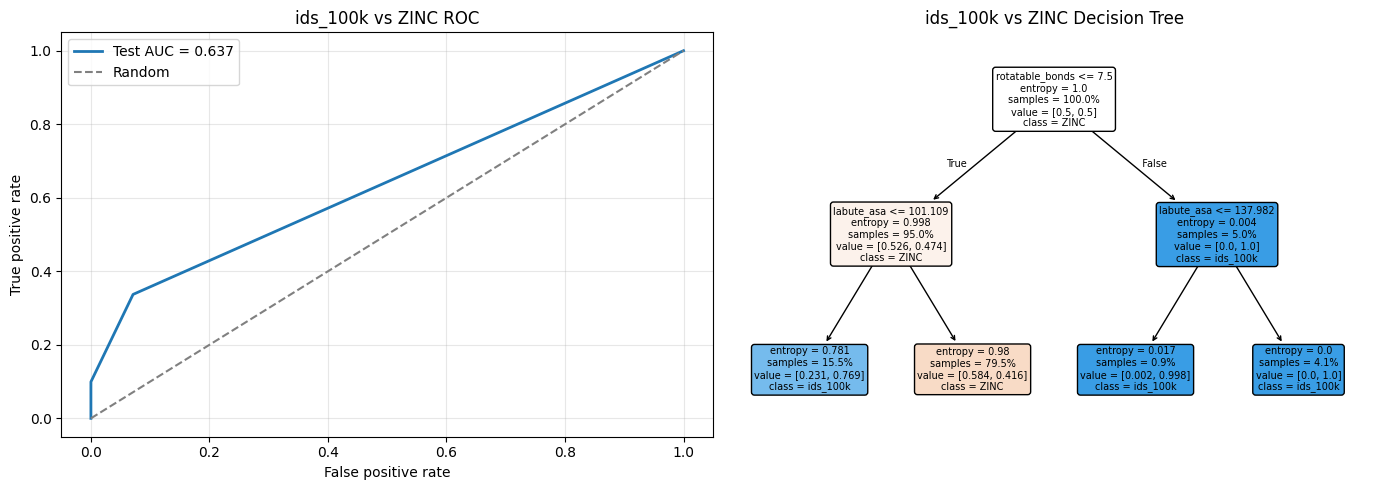


=== ids_100k vs DrugCentral ===
Samples per class: 4099
Training AUC: 0.628
Test AUC:     0.631

Decision tree rules:
|--- labute_asa <= 215.41
|   |--- log_p <= 0.87
|   |   |--- class: 0
|   |--- log_p >  0.87
|   |   |--- class: 1
|--- labute_asa >  215.41
|   |--- labute_asa <= 221.66
|   |   |--- class: 0
|   |--- labute_asa >  221.66
|   |   |--- class: 0



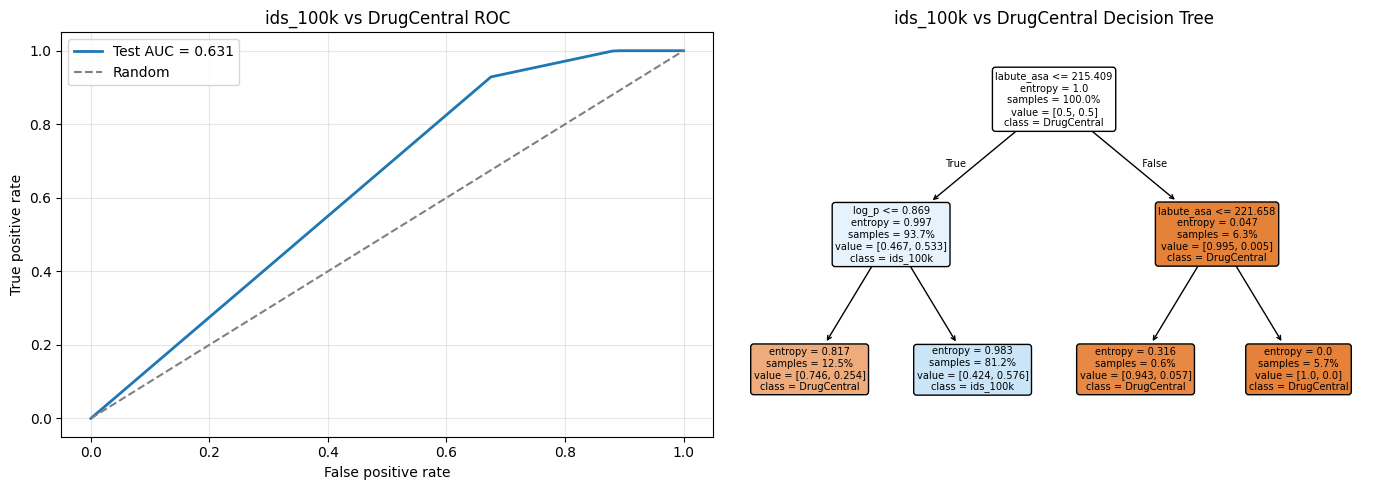

In [8]:
#lets run ids vs zinc
tree_ids_zinc, auc_ids_zinc = run_partition_model(
    ids_1k_props, zinc250, 'ids_100k', 'ZINC', 'ids_100k vs ZINC'
)


#lets run ids vs drug
tree_ids_drug, auc_ids_drug = run_partition_model(
    ids_1k_props, drug_df, 'ids_100k', 'DrugCentral', 'ids_100k vs DrugCentral'
)

Computing ring atom counts from SMILES ...


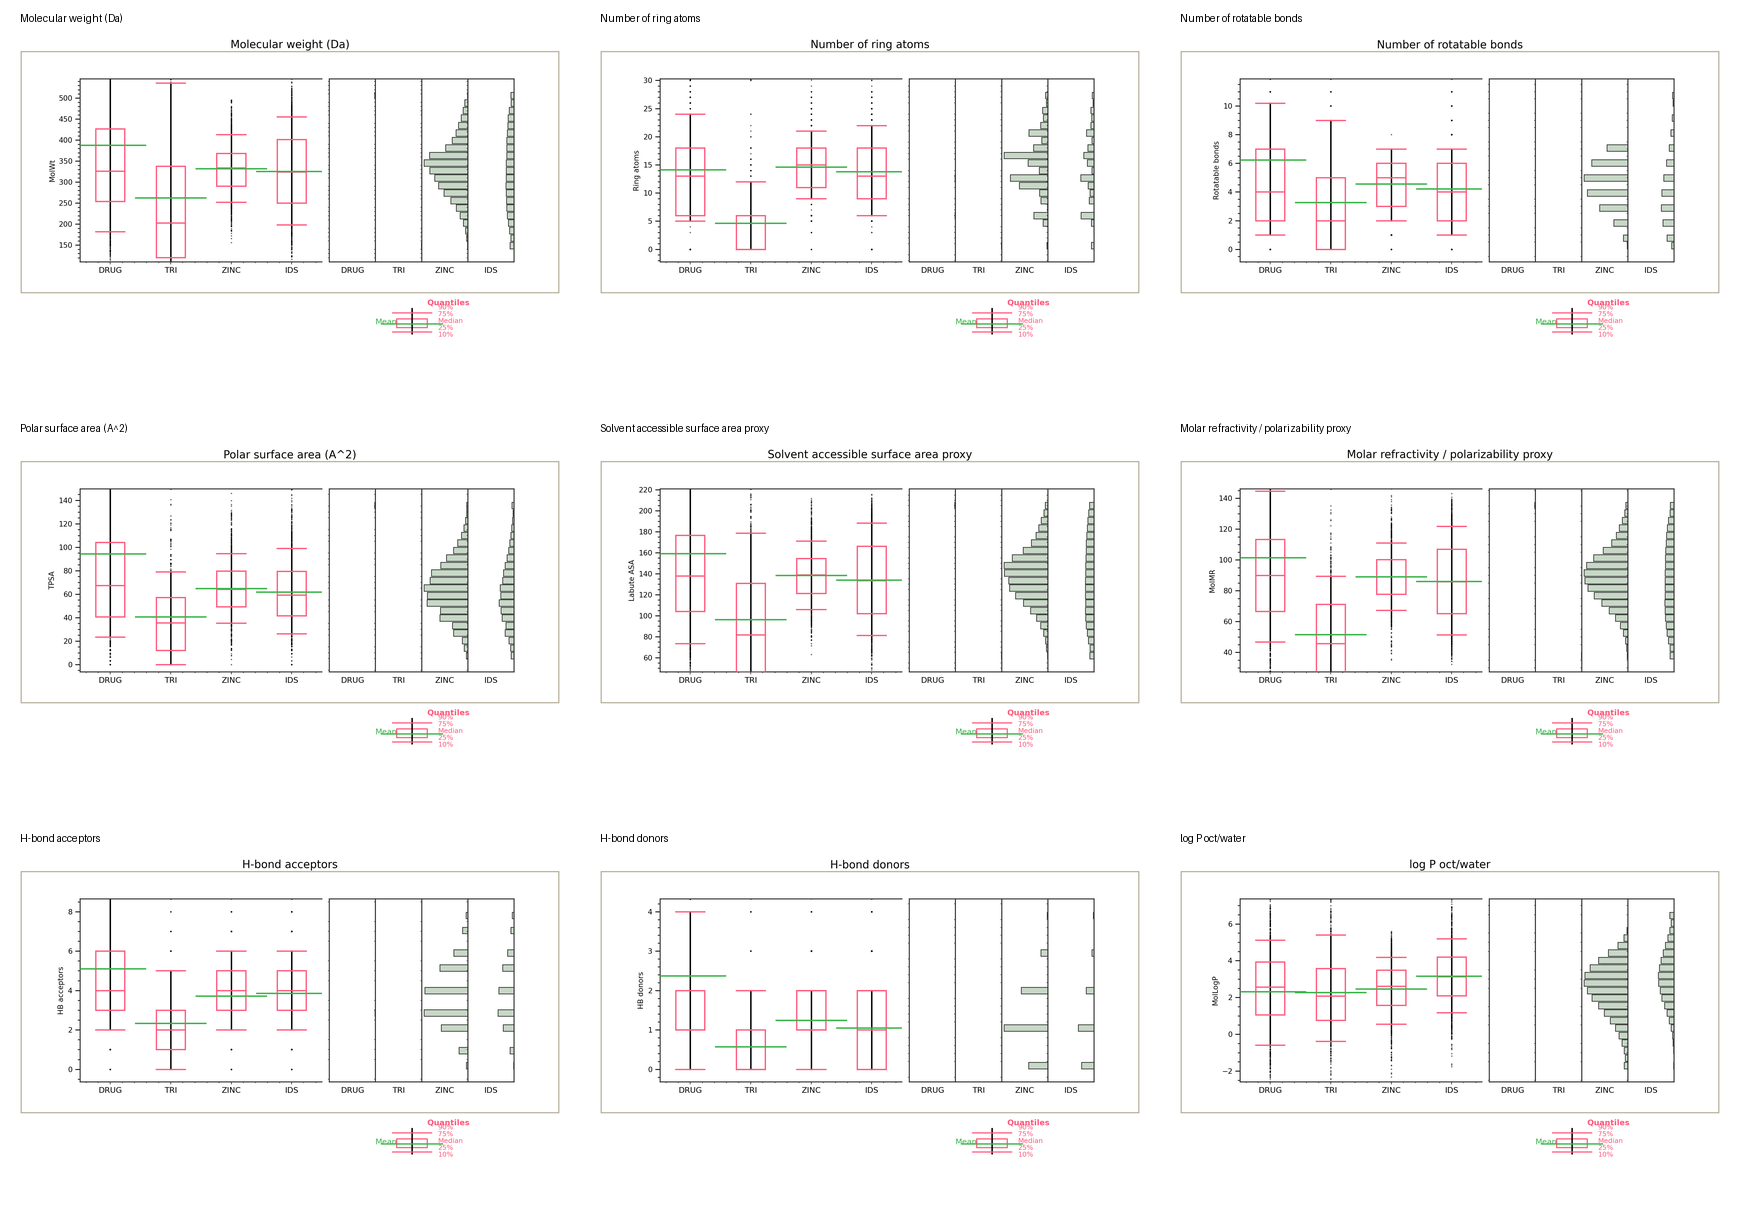

In [ ]:
import io
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import f_oneway
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from PIL import Image, ImageDraw
from rdkit import Chem, RDLogger
from IPython.display import display

# suppress minor warnings to keep the notebook output clean
warnings.filterwarnings("ignore")
# suppress RDKit C++ warnings/errors from cluttering output
RDLogger.DisableLog("rdApp.*")

# list of descriptors to plot and making sure that the captions are nice
DESCRIPTORS = [
    ("mol_weight",      "MolWt",          "Molecular weight (Da)"),
    ("num_ring_atoms",  "Ring atoms",     "Number of ring atoms"),
    ("rotatable_bonds", "Rotatable bonds","Number of rotatable bonds"),
    ("tpsa",            "TPSA",           "Polar surface area (A^2)"),
    ("labute_asa",      "Labute ASA",     "Solvent accessible surface area proxy"),
    ("mol_mr",          "MolMR",          "Molar refractivity / polarizability proxy"),
    ("h_acc",           "HB acceptors",   "H-bond acceptors"),
    ("h_donors",        "HB donors",      "H-bond donors"),
    ("log_p",           "MolLogP",        "log P oct/water"),
]

#all the datasets standardizing names
DATASETS = [
    ("drug", drug_df,      "DRUG"),
    ("tri",  tri_df,       "TRI"),
    ("zinc", zinc250,      "ZINC"),
    ("ids",  ids_1k_props, "IDS"),
]

# we ddidnt already calculate ring atom count so we do it here
def _ring_atom_count(smiles):
    #do we have smiles??
    if pd.isna(smiles) or not isinstance(smiles, str):
        return np.nan
    # rdkit mol object
    mol = Chem.MolFromSmiles(smiles)
    #count them up so sum for is in ring
    return float(sum(1 for a in mol.GetAtoms() if a.IsInRing())) if mol else np.nan

def build_combo(datasets):
    #build our big datset
    frames = []
    for key, df, _ in datasets:
        tmp = df.copy()
        tmp["dataset"] = key

        # make all the smiles columns the same name 'smiles'
        scol = next((c for c in tmp.columns if c.lower() in ("smiles", "canonical_smiles")), None)
        if scol:
            tmp = tmp.rename(columns={scol: "smiles"})

        frames.append(tmp)

    # stack dfs
    combo = pd.concat(frames, ignore_index=True)

    # compute num ring atoms using our function from above
    if "num_ring_atoms" not in combo.columns:
        print("Computing ring atom counts from SMILES ...")
        combo["num_ring_atoms"] = combo["smiles"].map(_ring_atom_count)

    return combo


def jmp_style_plot(combo, desc, ylabel, title, groups, group_labels):
    #gerenates our plot
    
    # extract the specific descriptor column for each group, ignoring NaNs
    data = [pd.to_numeric(combo.loc[combo.dataset == g, desc], errors="coerce").dropna() for g in groups]
    allvals = pd.concat(data)

    # clip outliers so its nice looking
    lo, hi = allvals.quantile(0.005), allvals.quantile(0.995)
    pad = (hi - lo) * 0.08 if hi > lo else 1
    ymin, ymax = lo - pad, hi + pad
    bins = np.linspace(lo, hi, 22) # 22 bins for the histograms

    # plot colors like the paper
    pink, green, hist_face, hist_edge = "#ff5a7d", "#3bb44a", "#c7d8c6", "#303030"

    fig = plt.figure(figsize=(10.8, 6.6), dpi=190, facecolor="white") #main figure of the plot
    gs = GridSpec(2, 1, height_ratios=[4.2, 1.25], hspace=0.22, figure=fig)
    top = gs[0].subgridspec(1, 2, width_ratios=[1.9, 1.45], wspace=0.035) #adds subgrid histogram

    ax_box = fig.add_subplot(top[0])
    ax_hists = [fig.add_subplot(top[1].subgridspec(1, len(groups), wspace=0)[i], sharey=ax_box) for i in range(len(groups))]
    ax_foot = fig.add_subplot(gs[1])
    ax_foot.axis("off") # turn off borders for the footer section

    # draw a large border rectangle around the plots
    fig.add_artist(Rectangle((0.02, 0.255), 0.96, 0.705, transform=fig.transFigure, fill=False, edgecolor="#b7b09d", lw=1.6))

    #making our box and whisker plots
    for x, (grp, series) in enumerate(zip(groups, data), start=1):
        # getting our quantiles for the plots
        q10, q25, q50, q75, q90 = series.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
        mean = series.mean()

        # sample 250 of our outliers
        tails = series[(series < q10) | (series > q90)]
        if len(tails) > 250:
            tails = tails.sample(250, random_state=42)

        # now scatter the tail points make them clear looking
        ax_box.scatter(np.full(len(tails), x), tails.clip(ymin, ymax), s=4, c="black", alpha=0.55, lw=0, zorder=1)
        
        # centerline
        ax_box.plot([x, x], [q10, q90], color="black", lw=2, zorder=2)
        
        # the 25-75 box
        ax_box.add_patch(Rectangle((x - 0.24, q25), 0.48, q75 - q25, fill=False, edgecolor=pink, lw=1.8, zorder=3))
        
        # median and lines for 90 10 bounds
        for yv in (q10, q50, q90):
            ax_box.plot([x - 0.24, x + 0.24], [yv, yv], color=pink, lw=1.8, zorder=4)
        
        # the mean line for each
        ax_box.plot([x - 0.58, x + 0.58], [mean, mean], color=green, lw=2, zorder=4)

    # formats the axes
    ax_box.set(xlim=(0.5, len(groups) + 0.5), ylim=(ymin, ymax), ylabel=ylabel)
    ax_box.set_xticks(range(1, len(groups) + 1))
    ax_box.set_xticklabels([group_labels[g] for g in groups], fontsize=11)
    ax_box.minorticks_on()
    ax_box.tick_params(axis="y", which="major", length=7, width=1.2)
    ax_box.tick_params(axis="y", which="minor", length=3.5, width=1)
    for sp in ax_box.spines.values():
        sp.set_linewidth(1.4)
        sp.set_color("#333333")
    ax_box.spines["right"].set_visible(False)

    # keep histogram x axis on same scale
    hist_counts = [np.histogram(series.clip(lo, hi), bins=bins)[0] for series in data]
    max_ct = max([c.max() for c in hist_counts]) if hist_counts else 1
    centres = (bins[:-1] + bins[1:]) / 2
    bar_h = np.diff(bins) * 0.86

    #draw the histograms
    for ax, grp, cts in zip(ax_hists, groups, hist_counts):
        ax.barh(centres, cts, height=bar_h, color=hist_face, edgecolor=hist_edge, lw=1)
        ax.set(ylim=(ymin, ymax), xlim=(0, max_ct * 1.05))
        ax.invert_xaxis() #
        ax.set_xticks([])
        ax.tick_params(axis="y", left=False, labelleft=False)
        ax.set_xlabel(group_labels[grp], fontsize=11, labelpad=7)
        for sp in ax.spines.values():
            sp.set_linewidth(1.4)
            sp.set_color("#333333")

    #one way anova for differnece in means
    f_val, p_val = f_oneway(*data)
    p_str = "<.0001" if p_val < 1e-4 else f"{p_val:.4f}"

    # labels and stuff
    ax_foot.text(0.20, 0.58, "Oneway Anova Analysis of Variance", fontsize=14, ha="left", va="center")
    ax_foot.text(0.31, 0.29, "F Ratio", fontsize=12, ha="center")
    ax_foot.text(0.31, 0.05, f"{f_val:.4f}", fontsize=12, ha="center")
    ax_foot.text(0.55, 0.29, "Prob > F", fontsize=12, ha="center")
    ax_foot.text(0.55, 0.05, p_str, fontsize=12, ha="center")

    t = ax_foot.transAxes
    ax_foot.text(0.80, 0.68, "Quantiles", color=pink, fontsize=11, fontweight="bold", ha="left", transform=t)
    ax_foot.text(0.825, 0.39, "90%\n75%\nMedian\n25%\n10%", color=pink, fontsize=9.5, ha="left", va="center", linespacing=1.05, transform=t)
    ax_foot.text(0.68, 0.33, "Mean", color=green, fontsize=11, ha="left", transform=t)

    # draw a visual legend diagram showing what the box plot lines mean
    lx, ly = 0.765, 0.34
    ax_foot.plot([lx, lx], [ly - 0.18, ly + 0.28], color="black", lw=2, transform=t) # Whisker
    ax_foot.add_patch(Rectangle((lx - 0.035, ly - 0.07), 0.07, 0.16, fill=False, edgecolor=pink, lw=1.6, transform=t)) # Box
    ax_foot.plot([lx - 0.045, lx + 0.045], [ly + 0.20, ly + 0.20], color=pink, lw=1.6, transform=t) # Top limit
    ax_foot.plot([lx - 0.045, lx + 0.045], [ly - 0.15, ly - 0.15], color=pink, lw=1.6, transform=t) # Bottom limit
    ax_foot.plot([lx - 0.07, lx + 0.07], [ly, ly], color=green, lw=1.8, transform=t) # Mean

    fig.suptitle(title, fontsize=15, y=0.995)

    # save plot to memory buffer instead of file
    buf = io.BytesIO()
    fig.savefig(buf, format="png", facecolor="white")
    plt.close(fig) # close so it doesn't display alone
    buf.seek(0)
    
    img = Image.open(buf).convert("RGB")
    return f_val, p_val, img

def make_contact_sheet(plots):
    """Stitches all individual descriptor plots into one large overview image (contact sheet)."""
    thumbs = []
    # process each plot generated
    for img, title in plots:
        # shrink the generated image down
        img.thumbnail((560, 360), Image.Resampling.LANCZOS)

        # create a small white canvas for the thumbnail and paste the image
        canvas = Image.new("RGB", (580, 410), "white")
        canvas.paste(img, ((580 - img.width) // 2, 38))
        # add the title text to the top left of the thumbnail
        ImageDraw.Draw(canvas).text((20, 12), title, fill=(0, 0, 0))
        thumbs.append(canvas)

    ncols = 3
    nrows = -(-len(thumbs) // ncols)
    # create the massive master canvas 
    sheet = Image.new("RGB", (ncols * 580, nrows * 410), "white")
    #tile the thumbnails onto the master canvas
    for i, th in enumerate(thumbs):
        #math to calculate (x, y) coordinates for a 3-column grid
        sheet.paste(th, ((i % ncols) * 580, (i // ncols) * 410))
    return sheet

# build combo
combo = build_combo(DATASETS)

#group order and label map
groups = [key for key, _, _ in DATASETS]
labels = {key: lbl for key, _, lbl in DATASETS}

# generate out plots and anova stuff
rows = []
plots = []
for desc, ylabel, title in DESCRIPTORS:
    f_val, p_val, img = jmp_style_plot(combo, desc, ylabel, title, groups, labels)
    plots.append((img, title))
    # Store the stat results
    rows.append({
        "descriptor": desc, "property": title, "f_ratio": f_val, "p_value": p_val
    })

# create the final compiled image and display it directly
contact_sheet = make_contact_sheet(plots)
display(contact_sheet)


# Fingerprint keys stuff

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys

ECFP_RADIUS = 2  # ECFP4
ECFP_NBITS = 2048
RDKIT_FP_SIZE = 2048


def mol_from_smiles(smiles: str):
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None


def structural_fingerprints(smiles: str) -> dict:
    """Return ECFP, RDKit, and MACCS fingerprints for one SMILES string."""
    mol = mol_from_smiles(smiles)
    if mol is None:
        return {"ecfp": None, "rdkit_fp": None, "maccs": None}

    ecfp = np.array(
        AllChem.GetMorganFingerprintAsBitVect(mol, radius=ECFP_RADIUS, nBits=ECFP_NBITS),
        dtype=np.uint8,
    )
    rdkit_fp = np.array(Chem.RDKFingerprint(mol, fpSize=RDKIT_FP_SIZE), dtype=np.uint8)
    maccs = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.uint8)
    return {"ecfp": ecfp, "rdkit_fp": rdkit_fp, "maccs": maccs}


fp_df = pd.DataFrame(df["smiles"].map(structural_fingerprints).tolist())
df = pd.concat([df.reset_index(drop=True), fp_df], axis=1)

n_failed = df["ecfp"].isna().sum()
print(f"Computed fingerprints for {len(df) - n_failed:,} / {len(df):,} molecules")
print(f"ECFP shape: {df['ecfp'].dropna().iloc[0].shape}")
print(f"RDKit FP shape: {df['rdkit_fp'].dropna().iloc[0].shape}")
print(f"MACCS shape: {df['maccs'].dropna().iloc[0].shape}")
df[["smiles", "ecfp", "rdkit_fp", "maccs"]].head()